<a href="https://colab.research.google.com/github/Achyuth060/ML-24148/blob/main/DECISION_TREE/CH_SC_U4CSE24148(Decision_tree2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("CH.SC.U4CSE24148_EX-7.6_2(Decision tree).csv")

data.head()

,Weather,Go_Out
0,Sunny,Go Out
1,Sunny,Go Out
2,Sunny,Go Out
3,Sunny,Go Out
4,Sunny,Go Out


In [3]:
data.shape

(15, 2)

In [4]:
data.isnull().sum()

,0
Weather,0
Go_Out,0


In [5]:
le_weather = LabelEncoder()
le_goout = LabelEncoder()

data["Weather"] = le_weather.fit_transform(data["Weather"])
data["Go_Out"] = le_goout.fit_transform(data["Go_Out"])

data.head()

,Weather,Go_Out
0,2,0
1,2,0
2,2,0
3,2,0
4,2,0


In [6]:
X = data[["Weather"]]
y = data["Go_Out"]

print(X.head())
print(y.head())

   Weather
0        2
1        2
2        2
3        2
4        2
0    0
1    0
2    0
3    0
4    0
Name: Go_Out, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(12, 1)
(12,)
(3, 1)
(3,)


In [8]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=5
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(y_pred)

[1 0 1]


In [9]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

accuracy_score = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy_score)
print("Accuracy in Percentage:", int(accuracy_score * 100), "%")

Confusion Matrix:
[[1 0]
 [0 2]]
Accuracy Score: 1.0
Accuracy in Percentage: 100 %


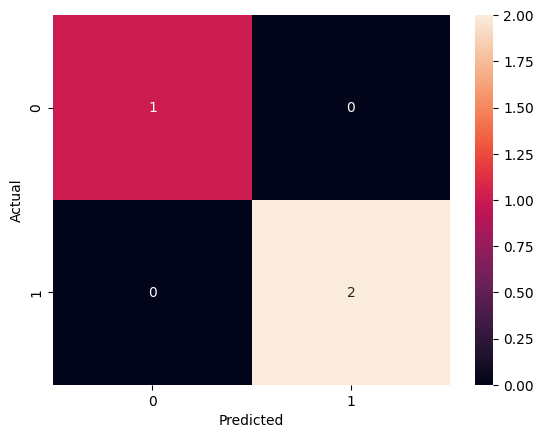

In [10]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

sns.heatmap(
    conf_mat,
    annot=True
)

plt.show()